# Project 708 - Book Recommendation System
## EDA, Feature Engineering and Model Building

**Business objective:** Generate features from the dataset and use them to recommend books to users.

**Datasets:** `Users.csv` (user id, location, age), `Books.csv` (ISBN, title, author, year, publisher), `Ratings.csv` (user id, ISBN, rating 0-10)

**Models built in this notebook:**
1. Popularity-Based
2. Content-Based Filtering
3. User-Based Collaborative Filtering
4. Item-Based Collaborative Filtering
5. SVD (Matrix Factorization)

**Flow of the notebook:** Load data -> Understand data -> Clean data -> Basic EDA -> Feature Engineering -> Model Building -> Evaluation -> Recommendations

## 1. Importing Libraries

In [1]:
import re
import html
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_columns', 30)

## 2. Loading the Data
Change the file paths below if your CSV files are saved somewhere else. `latin-1` encoding is used because the books file has special characters.

In [2]:
BOOKS_PATH   = 'Books.csv'
RATINGS_PATH = 'Ratings.csv'
USERS_PATH   = 'Users.csv'

books   = pd.read_csv(BOOKS_PATH,   encoding='latin-1', low_memory=False)
ratings = pd.read_csv(RATINGS_PATH, encoding='latin-1')
users   = pd.read_csv(USERS_PATH,   encoding='latin-1')

print('Books   :', books.shape)
print('Ratings :', ratings.shape)
print('Users   :', users.shape)

Books   : (271360, 8)
Ratings : (1149780, 3)
Users   : (278858, 3)


## 3. Understanding the Data

In [3]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.01.THUMBZZZ...,http://images.amazon.com/images/P/0195153448.01.MZZZZZZZ...,http://images.amazon.com/images/P/0195153448.01.LZZZZZZZ...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.01.THUMBZZZ...,http://images.amazon.com/images/P/0002005018.01.MZZZZZZZ...,http://images.amazon.com/images/P/0002005018.01.LZZZZZZZ...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.01.THUMBZZZ...,http://images.amazon.com/images/P/0060973129.01.MZZZZZZZ...,http://images.amazon.com/images/P/0060973129.01.LZZZZZZZ...
3,0374157065,Flu: The Story of the Great Influenza Pandemic of 1918 a...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.01.THUMBZZZ...,http://images.amazon.com/images/P/0374157065.01.MZZZZZZZ...,http://images.amazon.com/images/P/0374157065.01.LZZZZZZZ...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.01.THUMBZZZ...,http://images.amazon.com/images/P/0393045218.01.MZZZZZZZ...,http://images.amazon.com/images/P/0393045218.01.LZZZZZZZ...


In [4]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [5]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [6]:
print('---- BOOKS INFO ----')
books.info()
print()
print('---- RATINGS INFO ----')
ratings.info()
print()
print('---- USERS INFO ----')
users.info()

---- BOOKS INFO ----
<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ISBN                 271360 non-null  str  
 1   Book-Title           271360 non-null  str  
 2   Book-Author          271358 non-null  str  
 3   Year-Of-Publication  271360 non-null  str  
 4   Publisher            271358 non-null  str  
 5   Image-URL-S          271360 non-null  str  
 6   Image-URL-M          271360 non-null  str  
 7   Image-URL-L          271357 non-null  str  
dtypes: str(8)
memory usage: 16.6 MB

---- RATINGS INFO ----


<class 'pandas.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   User-ID      1149780 non-null  int64
 1   ISBN         1149780 non-null  str  
 2   Book-Rating  1149780 non-null  int64
dtypes: int64(2), str(1)
memory usage: 26.3 MB

---- USERS INFO ----
<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.4 MB


**Missing values and duplicates**

In [7]:
print('Missing values in Books:')
print(books.isnull().sum())
print()
print('Missing values in Users:')
print(users.isnull().sum())
print()
print('Missing values in Ratings:')
print(ratings.isnull().sum())
print()
print('Duplicate rows -> Books:', books.duplicated().sum(),
      '| Users:', users.duplicated().sum(),
      '| Ratings:', ratings.duplicated().sum())
print('Duplicate (user, book) pairs in Ratings:', ratings.duplicated(subset=['User-ID', 'ISBN']).sum())

Missing values in Books:


ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Missing values in Users:
User-ID          0
Location         0
Age         110762
dtype: int64

Missing values in Ratings:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64



Duplicate rows -> Books: 0 | Users: 0 | Ratings: 0


Duplicate (user, book) pairs in Ratings: 0


**Quick notes from this step**
- `Age` in Users has a lot of missing values, and some ages look wrong (like 0 or 244), so this column needs cleaning.
- `Year-Of-Publication` in Books is stored as text. A few rows are shifted (publisher name sitting in the year column), and some years are 0 or in the future.
- Books has very few missing values (author, publisher, image URL).
- Ratings has no duplicate (user, book) pairs, which is good for building the user-item matrix later.

## 4. Data Cleaning
Steps: rename columns to simple names, fix the year column, fix the age column, split location into city / state / country, drop image URLs (not needed), and keep only the ratings whose ISBN exists in the Books file.

In [8]:
# 1) simple column names
books.columns   = ['isbn', 'title', 'author', 'year', 'publisher', 'img_s', 'img_m', 'img_l']
users.columns   = ['user_id', 'location', 'age']
ratings.columns = ['user_id', 'isbn', 'rating']

# 2) drop image columns
books = books.drop(columns=['img_s', 'img_m', 'img_l'])

# 3) year: convert to number, wrong values become NaN, then fill with median
books['year'] = pd.to_numeric(books['year'], errors='coerce')
books.loc[(books['year'] < 1900) | (books['year'] > 2024), 'year'] = np.nan
print('Books with invalid / missing year:', books['year'].isnull().sum())
books['year'] = books['year'].fillna(books['year'].median())
books['year'] = books['year'].astype(int)

# 4) author / publisher missing -> 'Unknown'
books['author']    = books['author'].fillna('Unknown')
books['publisher'] = books['publisher'].fillna('Unknown')

# 4b) text has html codes like '&amp;' -> convert to normal characters
for col in ['title', 'author', 'publisher']:
    books[col] = books[col].apply(html.unescape)

# 5) age: keep only realistic ages (5 to 100), others become NaN
users['age_missing'] = users['age'].isnull() | (users['age'] < 5) | (users['age'] > 100)
users.loc[(users['age'] < 5) | (users['age'] > 100), 'age'] = np.nan
print('Users with missing / invalid age:', users['age'].isnull().sum())

# 6) location -> city, state, country
loc_parts = users['location'].str.split(',')
users['city']    = loc_parts.str[0].str.strip()
users['state']   = loc_parts.str[1].str.strip()
users['country'] = loc_parts.str[-1].str.strip()
users['country'] = users['country'].replace(['', 'n/a'], 'unknown').fillna('unknown')

# 7) keep only ratings whose book is present in books file
before = len(ratings)
ratings = ratings[ratings['isbn'].isin(books['isbn'])].reset_index(drop=True)
print('Ratings before:', before, '| after removing unknown ISBNs:', len(ratings))

Books with invalid / missing year: 4637


Users with missing / invalid age: 112010


Ratings before: 1149780 | after removing unknown ISBNs: 1031136


In [9]:
# separate explicit (1-10) and implicit (0) ratings
explicit = ratings[ratings['rating'] > 0].copy()
implicit = ratings[ratings['rating'] == 0].copy()
print('Explicit ratings (1-10):', len(explicit))
print('Implicit ratings (0)   :', len(implicit))

Explicit ratings (1-10): 383842
Implicit ratings (0)   : 647294


## 5. Basic EDA
Only basic plots here: rating distributions, user age and country, book year / author / publisher, and how active users and books are.

### 5.1 Rating distribution (all ratings including 0)

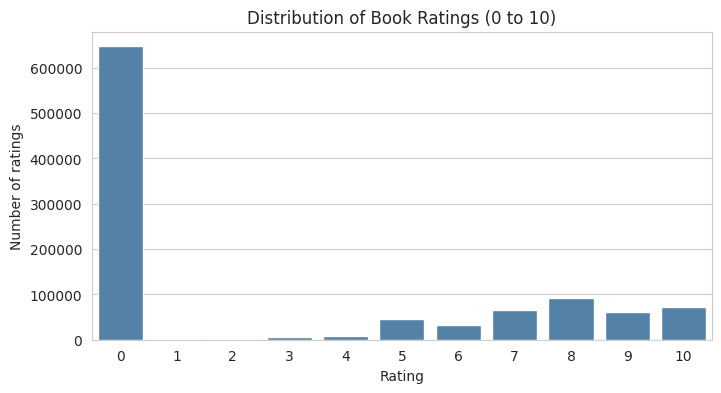

In [10]:
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=ratings, color='steelblue')
plt.title('Distribution of Book Ratings (0 to 10)')
plt.xlabel('Rating')
plt.ylabel('Number of ratings')
plt.show()

**What is this graph for?** It shows how many times each rating (0 to 10) was given. We plot it first to see what the rating column looks like before using it in any model.

**What we see:** Rating 0 is by far the biggest bar: about 62.8% of all ratings (647,294 out of 1,031,136) are 0. Among the real ratings (1-10), the high ratings (7, 8, 9, 10) are the most common.

### 5.2 Explicit vs Implicit ratings

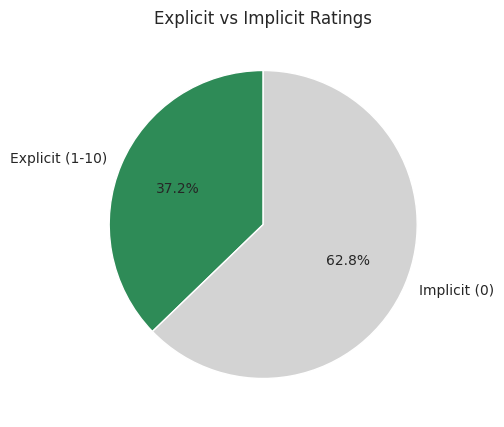

In [11]:
plt.figure(figsize=(5, 5))
plt.pie([len(explicit), len(implicit)], labels=['Explicit (1-10)', 'Implicit (0)'],
        autopct='%1.1f%%', colors=['seagreen', 'lightgray'], startangle=90)
plt.title('Explicit vs Implicit Ratings')
plt.show()

**What is this graph for?** It compares the share of real ratings (1-10) against implicit ratings (0, meaning the user interacted with the book but did not give a score). This decides which ratings we can use to train rating based models.

**What we see:** Only about 37% of the ratings are explicit (1-10). The remaining 63% are implicit (0), which we cannot treat as 'liked' or 'disliked'. So for rating based models we use only the explicit ratings.

### 5.3 Explicit rating distribution (1 to 10 only)

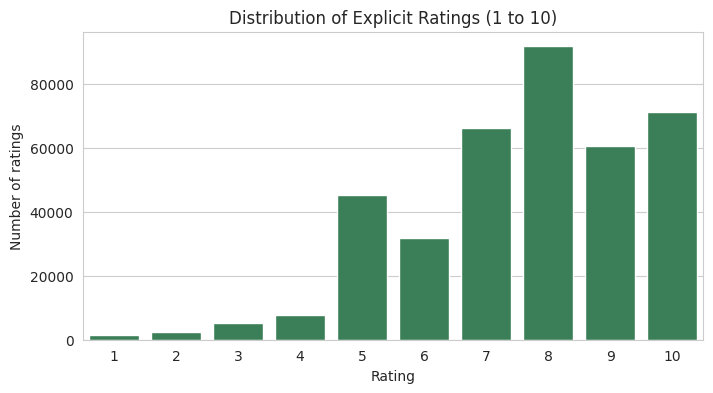

Average explicit rating: 7.63


In [12]:
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=explicit, color='seagreen')
plt.title('Distribution of Explicit Ratings (1 to 10)')
plt.xlabel('Rating')
plt.ylabel('Number of ratings')
plt.show()

print('Average explicit rating:', round(explicit['rating'].mean(), 2))

**What is this graph for?** It shows the real rating behaviour of users after removing the 0s. It tells us whether users are generous or strict and what the average rating is.

**What we see:** Users are generous raters. The average rating is 7.63, and 8 is the most common rating (about 24%), followed by 10 and 7. About 76% of ratings are 7 or above and only about 4% are 4 or below. There is also a small bump at 5, which is probably users picking the middle value.

### 5.4 User age distribution

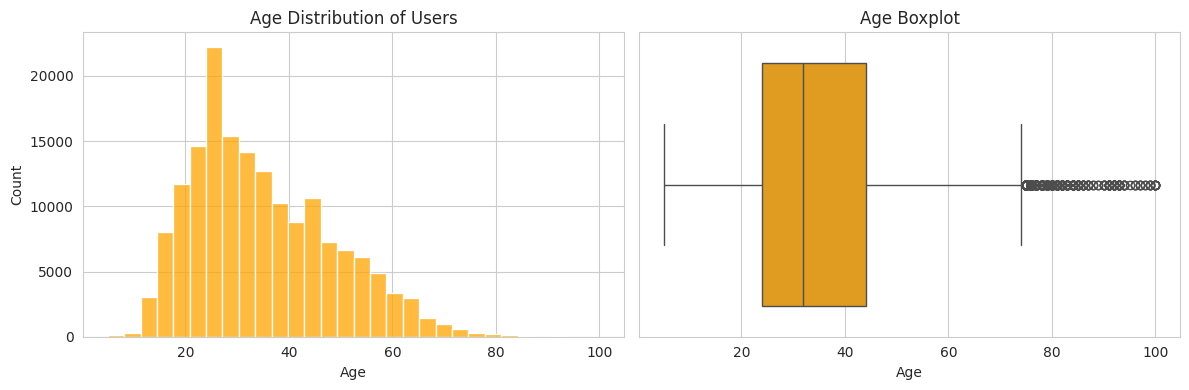

count    166848.000000
mean         34.746638
std          13.633051
min           5.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         100.000000
Name: age, dtype: float64


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(users['age'].dropna(), bins=30, color='orange', ax=ax[0])
ax[0].set_title('Age Distribution of Users')
ax[0].set_xlabel('Age')

sns.boxplot(x=users['age'].dropna(), color='orange', ax=ax[1])
ax[1].set_title('Age Boxplot')
ax[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print(users['age'].describe())

**What is this graph for?** The histogram shows which age groups are present in the data and the boxplot shows the median and outliers. We use it to understand who our users are and to decide how to treat the missing ages.

**What we see:** Most users are between 20 and 45 years old (median age 32, mean about 35). The boxplot shows a few users above 80 who look like outliers. Also, about 40% of users have no valid age, so age cannot be the main feature for recommendations.

### 5.5 Top 10 countries of users

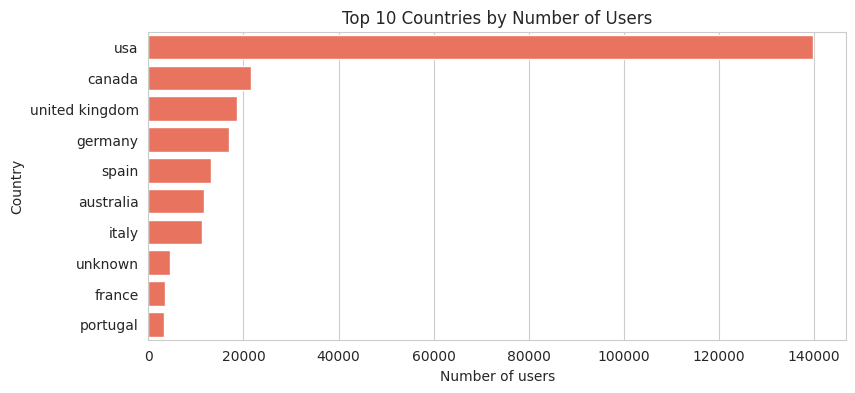

In [14]:
top_countries = users['country'].value_counts().head(10)

plt.figure(figsize=(9, 4))
sns.barplot(x=top_countries.values, y=top_countries.index, color='tomato')
plt.title('Top 10 Countries by Number of Users')
plt.xlabel('Number of users')
plt.ylabel('Country')
plt.show()

**What is this graph for?** It shows which countries most of the users come from. This helps us understand if the data is biased towards one region.

**What we see:** The USA alone is about 50% of all users (139,711), followed by Canada, United Kingdom, Germany and Spain. So the data is heavily biased towards English speaking countries.

### 5.6 Number of books published per year

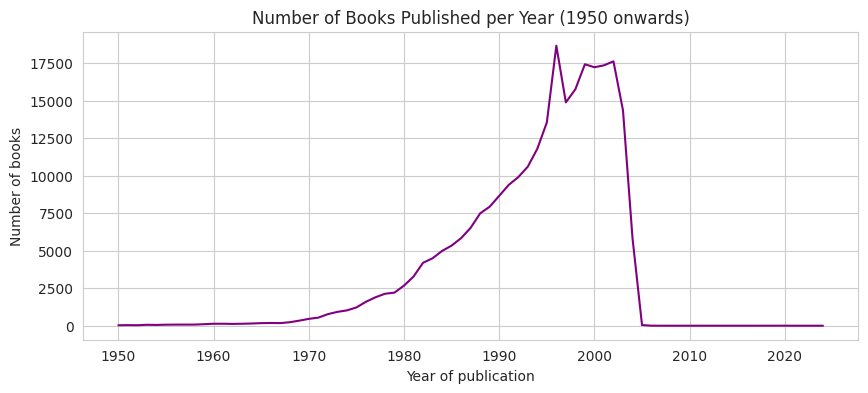

In [15]:
year_counts = books[books['year'] >= 1950]['year'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(year_counts.index, year_counts.values, color='purple')
plt.title('Number of Books Published per Year (1950 onwards)')
plt.xlabel('Year of publication')
plt.ylabel('Number of books')
plt.show()

**What is this graph for?** It shows in which years most of the books in our catalogue were published. We use it to check the age of the catalogue and to create the 'decade' feature later.

**What we see:** Most books in the catalogue were published in the 1990s and early 2000s (about 75% are from 1990 or later). The peak around 1996 is partly because we filled about 4.6k missing / wrong years with the median year.

### 5.7 Top 10 authors and publishers (by number of books)

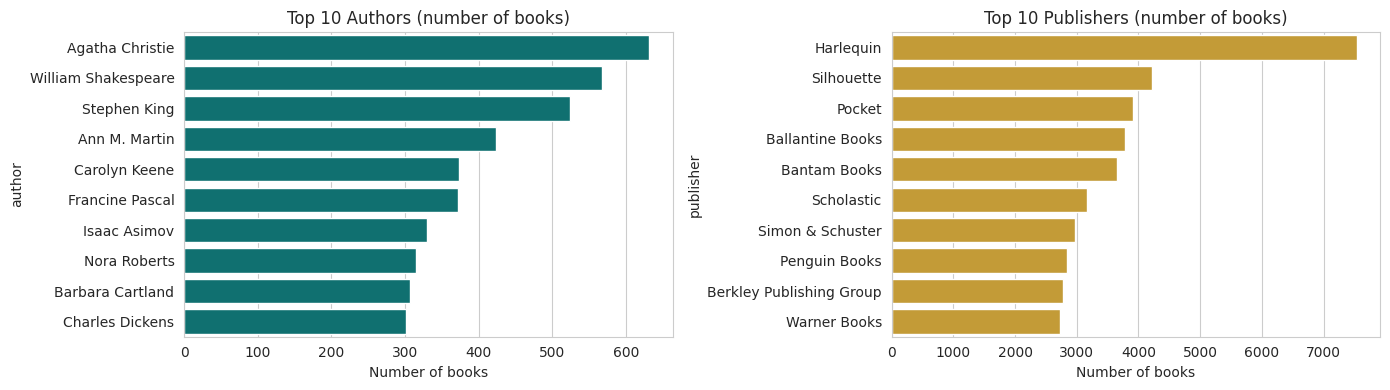

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

top_authors = books[books['author'] != 'Unknown']['author'].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index, color='teal', ax=ax[0])
ax[0].set_title('Top 10 Authors (number of books)')
ax[0].set_xlabel('Number of books')

top_pub = books[books['publisher'] != 'Unknown']['publisher'].value_counts().head(10)
sns.barplot(x=top_pub.values, y=top_pub.index, color='goldenrod', ax=ax[1])
ax[1].set_title('Top 10 Publishers (number of books)')
ax[1].set_xlabel('Number of books')

plt.tight_layout()
plt.show()

**What is this graph for?** It shows which authors and publishers have the most books in our catalogue. Author and publisher are used later as content features for the Content-Based model.

**What we see:** Agatha Christie, William Shakespeare and Stephen King have the most books. Among publishers, Harlequin is far ahead (7,535 books), followed by Silhouette, Pocket, Ballantine Books and Bantam Books.

### 5.8 How active are users and books?

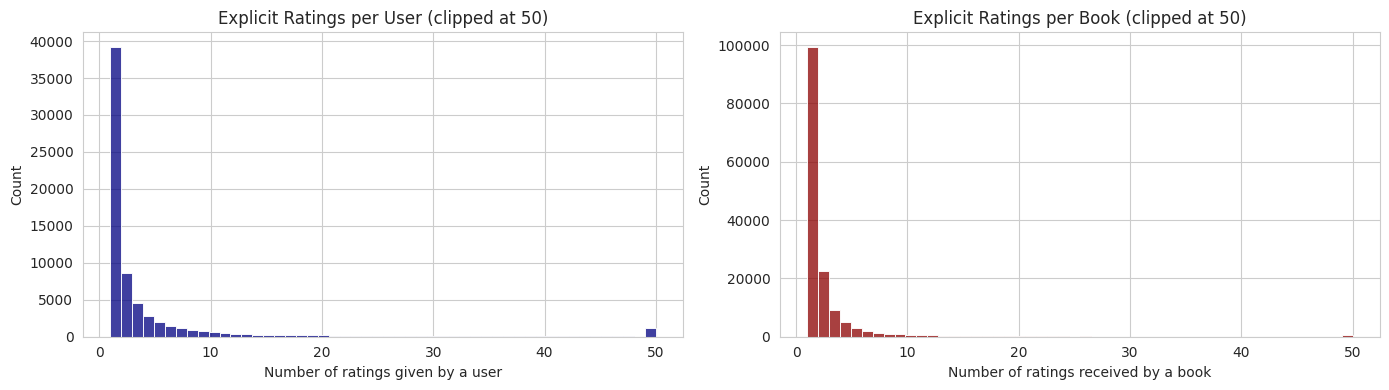

Users with explicit ratings : 68091
Books with explicit ratings : 149836
Median ratings per user     : 1.0
Median ratings per book     : 1.0
Users with only 1 rating    : 39223
Books with only 1 rating    : 99413


In [17]:
ratings_per_user = explicit.groupby('user_id')['rating'].count()
ratings_per_book = explicit.groupby('isbn')['rating'].count()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(ratings_per_user.clip(upper=50), bins=50, color='navy', ax=ax[0])
ax[0].set_title('Explicit Ratings per User (clipped at 50)')
ax[0].set_xlabel('Number of ratings given by a user')

sns.histplot(ratings_per_book.clip(upper=50), bins=50, color='darkred', ax=ax[1])
ax[1].set_title('Explicit Ratings per Book (clipped at 50)')
ax[1].set_xlabel('Number of ratings received by a book')

plt.tight_layout()
plt.show()

print('Users with explicit ratings :', ratings_per_user.shape[0])
print('Books with explicit ratings :', ratings_per_book.shape[0])
print('Median ratings per user     :', ratings_per_user.median())
print('Median ratings per book     :', ratings_per_book.median())
print('Users with only 1 rating    :', (ratings_per_user == 1).sum())
print('Books with only 1 rating    :', (ratings_per_book == 1).sum())

**What is this graph for?** It shows how many ratings each user gives and how many each book receives (values above 50 are clipped so the graph is readable). This tells us how sparse the data is, which is very important for collaborative filtering.

**What we see:** Both graphs are heavily skewed to the left: most users give only 1 or 2 ratings and most books get only 1 or 2 ratings (median is 1 for both). About 58% of users and 66% of books have just one explicit rating. This is the biggest challenge of this project - the data is very sparse, so we must filter users and books before building collaborative filtering models.

### 5.9 Top 10 most rated books

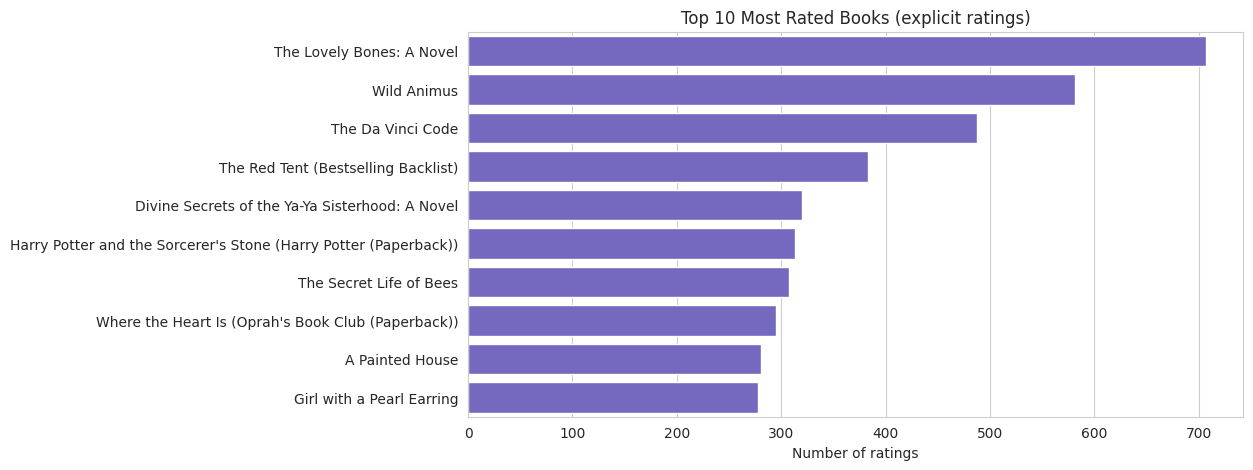

,title,count,mean
0,The Lovely Bones: A Novel,707,8.19
1,Wild Animus,581,4.39
2,The Da Vinci Code,487,8.44
3,The Red Tent (Bestselling Backlist),383,8.18
4,Divine Secrets of the Ya-Ya Sisterhood: A Novel,320,7.89
5,Harry Potter and the Sorcerer's Stone (Harry Potter (Pap...,313,8.94
6,The Secret Life of Bees,307,8.45
7,Where the Heart Is (Oprah's Book Club (Paperback)),295,8.14
8,A Painted House,281,7.34
9,Girl with a Pearl Earring,278,7.98


In [18]:
most_rated = (explicit.groupby('isbn')['rating'].agg(['count', 'mean'])
              .sort_values('count', ascending=False).head(10)
              .merge(books[['isbn', 'title']], on='isbn'))

plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='title', data=most_rated, color='slateblue')
plt.title('Top 10 Most Rated Books (explicit ratings)')
plt.xlabel('Number of ratings')
plt.ylabel('')
plt.show()

most_rated[['title', 'count', 'mean']].round(2)

**What is this graph for?** It shows the books that received the most ratings, i.e. the most popular books. This is the idea behind the Popularity-Based model.

**What we see:** The Lovely Bones, Wild Animus and The Da Vinci Code are the most rated books. Interesting point: Wild Animus has 581 ratings but an average of only 4.39, so a book can be popular (many ratings) without being liked. This is why the popularity model should also use the average rating and not only the count.

### 5.10 Top 10 highest average rated books (with at least 50 ratings)

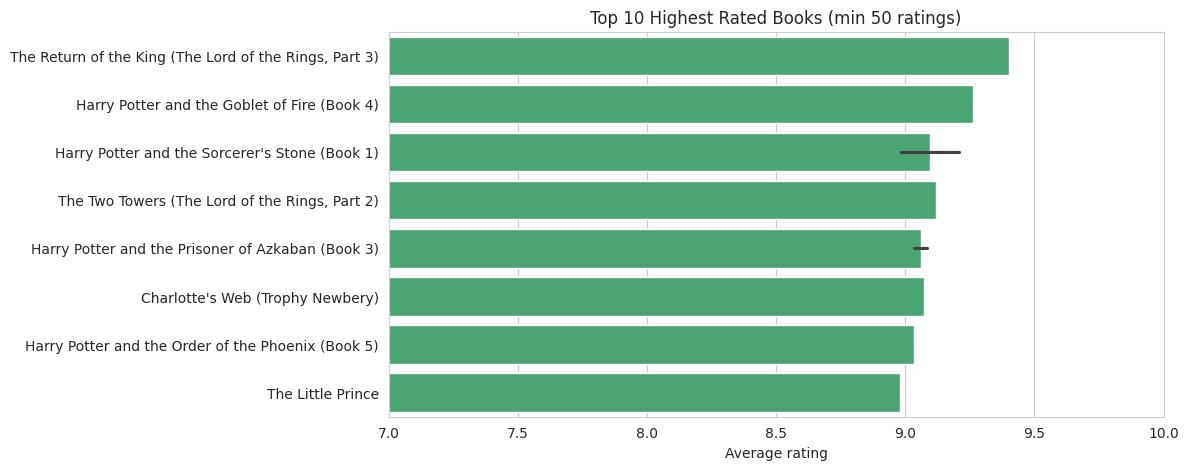

In [19]:
book_stats = explicit.groupby('isbn')['rating'].agg(['count', 'mean']).reset_index()
best_rated = (book_stats[book_stats['count'] >= 50]
              .sort_values('mean', ascending=False).head(10)
              .merge(books[['isbn', 'title']], on='isbn'))

plt.figure(figsize=(10, 5))
sns.barplot(x='mean', y='title', data=best_rated, color='mediumseagreen')
plt.xlim(7, 10)
plt.title('Top 10 Highest Rated Books (min 50 ratings)')
plt.xlabel('Average rating')
plt.ylabel('')
plt.show()

**What is this graph for?** It shows the best liked books (by average rating) after removing books with very few ratings. We use a minimum of 50 ratings because a book with one 10 rating is not reliable.

**What we see:** Harry Potter and Lord of the Rings books take the top spots with averages between about 9.1 and 9.4. Only 531 books have at least 50 ratings, which shows how few books have enough ratings to be judged reliably.

## 6. Feature Engineering
Creating new columns from the existing ones. These features help us understand users and books better and are also used for the Content-Based model.

**User features:** number of ratings, average rating given, age group, country
**Book features:** number of ratings, average rating, weighted rating, decade, title length, author book count, publisher book count, content tags

### 6.1 User features

In [20]:
user_feat = explicit.groupby('user_id')['rating'].agg(user_num_ratings='count', user_avg_rating='mean').reset_index()
user_feat['user_avg_rating'] = user_feat['user_avg_rating'].round(2)

users_fe = users.merge(user_feat, on='user_id', how='left')

# age group (users with missing age are kept as 'Unknown')
age_bins   = [0, 18, 25, 35, 50, 65, 100]
age_labels = ['<18', '18-25', '26-35', '36-50', '51-65', '65+']
users_fe['age_group'] = pd.cut(users_fe['age'], bins=age_bins, labels=age_labels).astype(object)
users_fe['age_group'] = users_fe['age_group'].fillna('Unknown')

# user type based on activity
users_fe['user_num_ratings'] = users_fe['user_num_ratings'].fillna(0)
users_fe['user_type'] = pd.cut(users_fe['user_num_ratings'], bins=[-1, 0, 5, 20, 1e9],
                               labels=['No explicit rating', 'Light (1-5)', 'Medium (6-20)', 'Heavy (20+)']).astype(object)

users_fe[['user_id', 'age', 'age_group', 'country', 'user_num_ratings', 'user_avg_rating', 'user_type']].head()

,user_id,age,age_group,country,user_num_ratings,user_avg_rating,user_type
0,1,NaN,Unknown,usa,0.0,NaN,No explicit rating
1,2,18.0,<18,usa,0.0,NaN,No explicit rating
2,3,NaN,Unknown,russia,0.0,NaN,No explicit rating
3,4,17.0,<18,portugal,0.0,NaN,No explicit rating
4,5,NaN,Unknown,united kingdom,0.0,NaN,No explicit rating


In [21]:
users_fe['user_type'].value_counts()

user_type
No explicit rating    210767
Light (1-5)            57307
Medium (6-20)           7646
Heavy (20+)             3138
Name: count, dtype: int64

### 6.2 Book features

In [22]:
# rating based features
book_feat = explicit.groupby('isbn')['rating'].agg(book_num_ratings='count', book_avg_rating='mean').reset_index()

# weighted rating (IMDB style) -> gives fair score to books with few ratings
#   WR = (v / (v + m)) * R + (m / (v + m)) * C
#   v = number of ratings of the book, R = avg rating of the book
#   m = minimum ratings needed (90th percentile of rating counts), C = overall mean rating
C = explicit['rating'].mean()
m = book_feat['book_num_ratings'].quantile(0.90)
v = book_feat['book_num_ratings']
R = book_feat['book_avg_rating']
book_feat['book_weighted_rating'] = (v / (v + m)) * R + (m / (v + m)) * C
print('C (overall mean rating) =', round(C, 2), '| m (minimum ratings) =', m)

books_fe = books.merge(book_feat, on='isbn', how='left')
books_fe[['book_num_ratings']] = books_fe[['book_num_ratings']].fillna(0)

# metadata features
books_fe['decade']             = (books_fe['year'] // 10) * 10
books_fe['title_length']       = books_fe['title'].str.len()
books_fe['title_word_count']   = books_fe['title'].str.split().str.len()
books_fe['author_book_count']  = books_fe.groupby('author')['isbn'].transform('count')
books_fe['publisher_book_count'] = books_fe.groupby('publisher')['isbn'].transform('count')

books_fe.head()

C (overall mean rating) = 7.63 | m (minimum ratings) = 4.0


,isbn,title,author,year,publisher,book_num_ratings,book_avg_rating,book_weighted_rating,decade,title_length,title_word_count,author_book_count,publisher_book_count
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,0.0,NaN,NaN,2000,19,2,2,1502
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,9.0,7.666667,7.654369,2000,12,2,2,15
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,2.0,7.500000,7.584467,1990,20,3,3,8
3,0374157065,Flu: The Story of the Great Influenza Pandemic of 1918 a...,Gina Bari Kolata,1999,Farrar Straus Giroux,6.0,7.833333,7.750680,1990,98,19,2,263
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company,0.0,NaN,NaN,1990,22,4,1,739


### 6.3 Content tags for the Content-Based model
For the content-based model every book needs some text describing it. We combine **author + publisher + title words** into one text column called `tags`. Author and publisher are joined into one word (for example `stephenking`) so that the model treats the whole name as one feature, and the author is repeated so it gets more weight.

In [23]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def join_words(text):
    # 'Stephen King' -> 'stephenking'
    return re.sub(r'[^a-z0-9]', '', str(text).lower())

books_fe['author_token']    = books_fe['author'].apply(join_words)
books_fe['publisher_token'] = books_fe['publisher'].apply(join_words)
books_fe['title_clean']     = books_fe['title'].apply(clean_text)

books_fe['tags'] = (books_fe['author_token'] + ' ' + books_fe['author_token'] + ' '
                    + books_fe['publisher_token'] + ' ' + books_fe['title_clean'])

books_fe[['title', 'author', 'publisher', 'tags']].head()

,title,author,publisher,tags
0,Classical Mythology,Mark P. O. Morford,Oxford University Press,markpomorford markpomorford oxforduniversitypress classi...
1,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,richardbrucewright richardbrucewright harperflamingocana...
2,Decision in Normandy,Carlo D'Este,HarperPerennial,carlodeste carlodeste harperperennial decision in normandy
3,Flu: The Story of the Great Influenza Pandemic of 1918 a...,Gina Bari Kolata,Farrar Straus Giroux,ginabarikolata ginabarikolata farrarstrausgiroux flu the...
4,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton & Company,ejwbarber ejwbarber wwnortoncompany the mummies of urumchi


### 6.4 Does age group / country affect the rating?

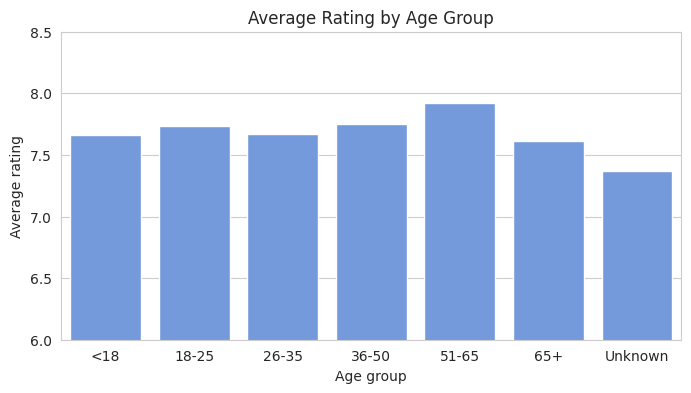

In [24]:
# attach user and book features to the explicit ratings
exp_full = (explicit.merge(users_fe[['user_id', 'age', 'age_group', 'country', 'user_num_ratings', 'user_avg_rating']], on='user_id', how='left')
                    .merge(books_fe[['isbn', 'year', 'book_num_ratings', 'book_avg_rating']], on='isbn', how='left'))

order = ['<18', '18-25', '26-35', '36-50', '51-65', '65+', 'Unknown']
plt.figure(figsize=(8, 4))
sns.barplot(x='age_group', y='rating', data=exp_full, order=order, color='cornflowerblue', errorbar=None)
plt.ylim(6, 8.5)
plt.title('Average Rating by Age Group')
plt.xlabel('Age group')
plt.ylabel('Average rating')
plt.show()

**What is this graph for?** It shows whether different age groups rate books differently. This is the reason we created the `age_group` feature.

**What we see:** Average ratings are close for all age groups (about 7.6 to 7.9). The 51-65 group rates slightly higher and users with unknown age rate slightly lower (7.37). The differences are small (note the y-axis starts from 6), so age group is only a weak feature.

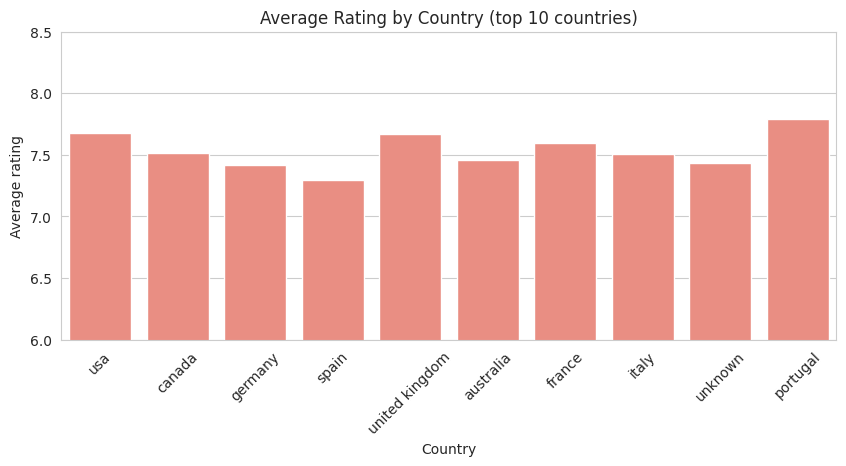

In [25]:
top10_c = users_fe['country'].value_counts().head(10).index
tmp = exp_full[exp_full['country'].isin(top10_c)]

plt.figure(figsize=(10, 4))
sns.barplot(x='country', y='rating', data=tmp, color='salmon', errorbar=None)
plt.ylim(6, 8.5)
plt.xticks(rotation=45)
plt.title('Average Rating by Country (top 10 countries)')
plt.xlabel('Country')
plt.ylabel('Average rating')
plt.show()

**What is this graph for?** It shows whether users from different countries rate differently on average.

**What we see:** Averages range from about 7.3 (Spain) to about 7.8 (Portugal), with the USA and UK around 7.7. The difference between countries is small, so country is also a weak feature.

### 6.5 Correlation between numeric features

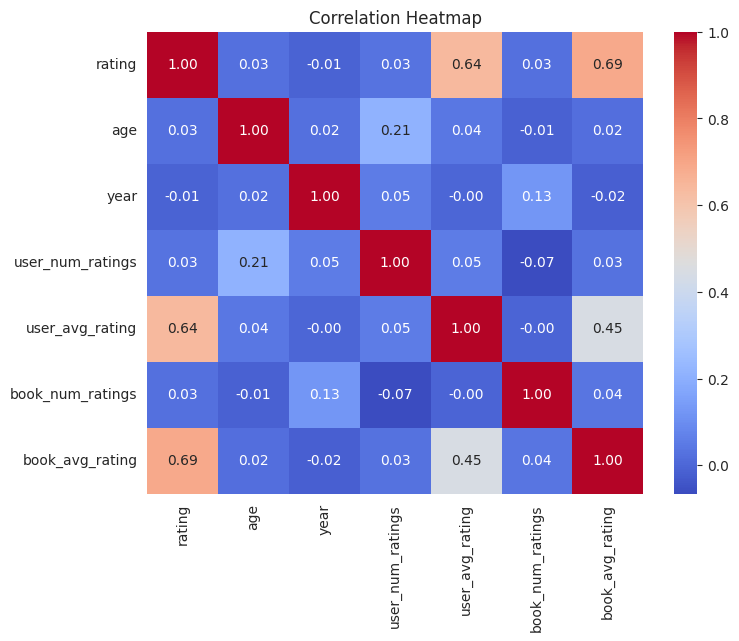

In [26]:
num_cols = ['rating', 'age', 'year', 'user_num_ratings', 'user_avg_rating', 'book_num_ratings', 'book_avg_rating']

plt.figure(figsize=(8, 6))
sns.heatmap(exp_full[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**What is this graph for?** It shows how strongly the numeric columns move together. We check it to see which features are related to the rating. (The user / book average columns include the rating itself, so their correlation looks higher than it really is.)

**What we see:** The rating has a strong correlation with book average rating (0.69) and user average rating (0.64). Both include the rating itself, so they look higher than they really are, but it shows that a user's own tendency and a book's quality both matter - this is exactly why we mean-center ratings and use user average in our models. Age, year of publication and number of ratings have almost no correlation (about 0.03 or less) with the rating.

## 7. Preparing Data for Model Building

**Which ratings do we use?** Only explicit ratings (1-10), because the 0 ratings do not tell us whether the user liked the book or not.

**Filtering:** The data is very sparse (most users rate only 1 or 2 books), so a recommender cannot learn anything from them. We keep users with at least **6** ratings and books with at least **8** ratings. We repeat the filter a few times because removing books can reduce a user's count (and the other way around). Stricter filters (like 20 and 20) removed almost the whole data, so these values are a balance between data size and quality.

In [27]:
MIN_USER_RATINGS = 6
MIN_BOOK_RATINGS = 8

df = explicit.copy()
for _ in range(10):
    df = df[df['user_id'].map(df['user_id'].value_counts()) >= MIN_USER_RATINGS]
    df = df[df['isbn'].map(df['isbn'].value_counts()) >= MIN_BOOK_RATINGS]
df = df.reset_index(drop=True)

n_users = df['user_id'].nunique()
n_items = df['isbn'].nunique()
print('Ratings used for modelling:', len(df))
print('Users:', n_users, '| Books:', n_items)
print('Matrix density: {:.2f}%'.format(len(df) / (n_users * n_items) * 100))

Ratings used for modelling: 74768
Users: 4289 | Books: 4001
Matrix density: 0.44%


In [28]:
# map user ids and isbns to row / column numbers of the matrix
user_ids = np.sort(df['user_id'].unique())
isbns    = np.sort(df['isbn'].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}
isbn2idx = {b: i for i, b in enumerate(isbns)}

df['u'] = df['user_id'].map(user2idx)
df['i'] = df['isbn'].map(isbn2idx)

# book details in the same order as the matrix columns
items_df = books_fe.set_index('isbn').loc[isbns].reset_index()

# train / test split (80 / 20)
train, test = train_test_split(df, test_size=0.2, random_state=42)
print('Train ratings:', len(train), '| Test ratings:', len(test))

Train ratings: 59814 | Test ratings: 14954


### 7.1 Building the user-item matrix
Rows = users, columns = books, values = ratings. Since most cells are empty we use a **sparse matrix**.

For collaborative filtering we also **mean-center** the ratings (rating minus the user's own average). This removes the effect of strict users (who always give low ratings) and generous users (who always give high ratings).

In [29]:
# user-item rating matrix (train only)
R = csr_matrix((train['rating'], (train['u'], train['i'])), shape=(n_users, n_items))

# 1 where a rating exists, 0 otherwise
B = csr_matrix((np.ones(len(train)), (train['u'], train['i'])), shape=(n_users, n_items))

# user average rating (from train only)
global_mean = train['rating'].mean()
user_mean = (train.groupby('u')['rating'].mean()
                  .reindex(range(n_users)).fillna(global_mean).values)

# mean-centered matrix
train = train.copy()
train['centered'] = train['rating'] - user_mean[train['u'].values]
Rc = csr_matrix((train['centered'], (train['u'], train['i'])), shape=(n_users, n_items))

print('Matrix shape:', R.shape)
print('Global mean rating:', round(global_mean, 2))

Matrix shape: (4289, 4001)
Global mean rating: 7.87


### 7.2 Evaluation functions
We evaluate in two ways:

1. **Rating prediction error (RMSE and MAE)** - how close is the predicted rating to the real rating on the test data. Lower is better.
2. **Top-10 recommendation quality** - for each user we recommend 10 books that the user has not rated in the train data and check how many of the books the user liked in the test data (rating >= 7) were recommended.
   - **Precision@10** = (liked books found in the 10 recommendations) / 10
   - **Recall@10** = (liked books found) / (all liked books of the user in test)
   - **Hit Rate@10** = share of users for whom at least 1 liked book was recommended

The ranking numbers look small because we have only a few ratings per user, so most good books are simply unrated. They are meant for **comparing models with each other**.

In [30]:
test_u = test['u'].values
test_i = test['i'].values
test_r = test['rating'].values

def rating_errors(score_matrix):
    pred = score_matrix[test_u, test_i]
    rmse = np.sqrt(np.mean((pred - test_r) ** 2))
    mae  = np.mean(np.abs(pred - test_r))
    return rmse, mae

# books already seen by each user in train (to remove from recommendations)
seen_train = train.groupby('u')['i'].apply(list).to_dict()
# books the user liked in test data
liked_test = test[test['rating'] >= 7].groupby('u')['i'].apply(set).to_dict()

def ranking_metrics(score_matrix, K=10):
    precisions, recalls, hits = [], [], []
    for u, liked in liked_test.items():
        s = score_matrix[u].astype(float).copy()
        s[seen_train.get(u, [])] = -np.inf
        top_k = np.argpartition(-s, K)[:K]
        found = len(liked.intersection(top_k))
        precisions.append(found / K)
        recalls.append(found / len(liked))
        hits.append(1 if found > 0 else 0)
    return np.mean(precisions), np.mean(recalls), np.mean(hits)

print('Users used for ranking evaluation:', len(liked_test))

Users used for ranking evaluation: 3496


## 8. Model Building

### Model 1: Popularity-Based
Recommends the same top books to everyone. A book is popular if it has many ratings **and** a good average rating. We use the same weighted rating formula from feature engineering, calculated on the **train data only**.

*Good for:* new users (cold start). *Weakness:* not personalised.

In [31]:
pop = train.groupby('i')['rating'].agg(['count', 'mean'])
C_tr = train['rating'].mean()
m_tr = pop['count'].quantile(0.90)
pop['wr'] = (pop['count'] / (pop['count'] + m_tr)) * pop['mean'] + (m_tr / (pop['count'] + m_tr)) * C_tr

pop_score_vec = pop['wr'].reindex(range(n_items)).fillna(C_tr).values
pop_scores = np.tile(pop_score_vec.astype(np.float32), (n_users, 1))

top_pop = pop.sort_values('wr', ascending=False).head(10)
top_pop_books = items_df.loc[top_pop.index, ['title', 'author']].copy()
top_pop_books['num_ratings'] = top_pop['count'].values
top_pop_books['avg_rating']  = top_pop['mean'].round(2).values
top_pop_books['weighted_rating'] = top_pop['wr'].round(2).values
top_pop_books.reset_index(drop=True)

,title,author,num_ratings,avg_rating,weighted_rating
0,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,82,9.39,9.01
1,"The Return of the King (The Lord of the Rings, Part 3)",J.R.R. TOLKIEN,42,9.60,8.92
2,Harry Potter and the Sorcerer's Stone (Harry Potter (Pap...,J. K. Rowling,133,9.11,8.90
3,Harry Potter and the Order of the Phoenix (Book 5),J. K. Rowling,124,9.09,8.87
4,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,83,9.17,8.85
5,To Kill a Mockingbird,Harper Lee,110,8.99,8.77
6,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,85,9.05,8.76
7,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,61,9.11,8.73
8,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,65,9.08,8.72
9,Dune (Remembering Tomorrow),Frank Herbert,39,9.31,8.72


### Model 2: Content-Based Filtering
Recommends books that are **similar in content** (author, publisher, title words) to the books the user already liked.

Steps:
1. Convert the `tags` text of each book into numbers using **TF-IDF**.
2. Find the similarity between every two books using **cosine similarity**.
3. To predict a rating for a user, take the books that the user has rated and combine them using the similarity to the new book.

In [32]:
# words like 'paperback' or 'novel' appear in thousands of titles and make unrelated books look similar, so we remove them too
extra_stop_words = ['paperback', 'hardcover', 'novel', 'book', 'books', 'edition', 'mass', 'market', 'series']
my_stop_words = list(TfidfVectorizer(stop_words='english').get_stop_words()) + extra_stop_words

tfidf = TfidfVectorizer(stop_words=my_stop_words)
tfidf_matrix = tfidf.fit_transform(items_df['tags'])
print('TF-IDF matrix shape (books x words):', tfidf_matrix.shape)

content_sim = cosine_similarity(tfidf_matrix).astype(np.float32)
print('Content similarity matrix:', content_sim.shape)

TF-IDF matrix shape (books x words): (4001, 5431)
Content similarity matrix: (4001, 4001)


### Model 3: User-Based Collaborative Filtering
Idea: *users who rated books similarly in the past will like similar books in the future.*

1. Find the similarity between users (cosine similarity on the mean-centered matrix).
2. For every user keep the **k most similar users** (neighbours).
3. Predicted rating = user's average + weighted average of what the neighbours rated above / below their own averages.

A small `shrink` value (0.5) is added in the denominator so that a book rated by only one neighbour does not get a very high predicted score. (We tried shrink = 0, 0.05, 0.2, 0.5 and 1 on the test data; 0 gives unstable predictions, and 0.5 to 1 gave the most stable results.)

In [33]:
def top_k_sim(S, k):
    # keep only positive similarities and the k highest per row (diagonal = the item/user itself, so removed)
    S = np.clip(S, 0, None).astype(np.float32)
    np.fill_diagonal(S, 0)
    drop = np.argpartition(-S, k, axis=1)[:, k:]
    np.put_along_axis(S, drop, 0, axis=1)
    return csr_matrix(S)

user_sim_full = cosine_similarity(Rc).astype(np.float32)
print('User similarity matrix:', user_sim_full.shape)

def user_cf_scores(k=30, shrink=0.5):
    S = top_k_sim(user_sim_full, k)
    num = (S @ Rc).toarray()
    den = (abs(S) @ B).toarray()
    return np.clip(user_mean[:, None] + num / (den + shrink), 1, 10).astype(np.float32)

# choosing k (number of neighbours) using RMSE on test data
user_rmse = {}
for k in [10, 30, 50, 100]:
    user_rmse[k] = rating_errors(user_cf_scores(k=k))[0]
    print('User-Based CF  k =', k, '-> RMSE =', round(user_rmse[k], 4))

best_k_user = min(user_rmse, key=user_rmse.get)
print('Best k:', best_k_user)

User similarity matrix: (4289, 4289)


User-Based CF  k = 10 -> RMSE = 1.6035


User-Based CF  k = 30 -> RMSE = 1.5993


User-Based CF  k = 50 -> RMSE = 1.5961


User-Based CF  k = 100 -> RMSE = 1.5891
Best k: 100


In [34]:
user_scores = user_cf_scores(k=best_k_user)

### Model 4: Item-Based Collaborative Filtering
Idea: *books that were rated similarly by the same users are similar books.* If you liked a book, you will like books similar to it.

The steps are the same as user-based, but now we find similarity between **books** (using the ratings given to them) instead of users.

In [35]:
item_sim_full = cosine_similarity(Rc.T).astype(np.float32)
print('Item similarity matrix:', item_sim_full.shape)

def item_cf_scores(sim_full, k=30, shrink=0.5):
    S = top_k_sim(sim_full, k)
    num = (Rc @ S.T).toarray()
    den = (B @ abs(S).T).toarray()
    return np.clip(user_mean[:, None] + num / (den + shrink), 1, 10).astype(np.float32)

item_rmse = {}
for k in [10, 30, 50, 100]:
    item_rmse[k] = rating_errors(item_cf_scores(item_sim_full, k=k))[0]
    print('Item-Based CF  k =', k, '-> RMSE =', round(item_rmse[k], 4))

best_k_item = min(item_rmse, key=item_rmse.get)
print('Best k:', best_k_item)

Item similarity matrix: (4001, 4001)


Item-Based CF  k = 10 -> RMSE = 1.594


Item-Based CF  k = 30 -> RMSE = 1.5914


Item-Based CF  k = 50 -> RMSE = 1.5905


Item-Based CF  k = 100 -> RMSE = 1.5883
Best k: 100


In [36]:
item_scores = item_cf_scores(item_sim_full, k=best_k_item)

# content-based scores use the same formula, only the similarity matrix is different (content similarity)
content_rmse = {}
for k in [10, 30, 50, 100]:
    content_rmse[k] = rating_errors(item_cf_scores(content_sim, k=k))[0]
    print('Content-Based  k =', k, '-> RMSE =', round(content_rmse[k], 4))

best_k_content = min(content_rmse, key=content_rmse.get)
print('Best k:', best_k_content)

Content-Based  k = 10 -> RMSE = 1.5724


Content-Based  k = 30 -> RMSE = 1.5684


Content-Based  k = 50 -> RMSE = 1.5679


Content-Based  k = 100 -> RMSE = 1.5679
Best k: 50


In [37]:
content_scores = item_cf_scores(content_sim, k=best_k_content)

### Model 5: SVD (Matrix Factorization)
SVD breaks the big user-book matrix into small matrices of hidden (latent) factors - for example a hidden factor could be "likes thrillers". Users and books are described by these factors, and the predicted rating is calculated from them. The number of factors is called `n_components`.

In [38]:
def svd_scores(n_components=50):
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    user_factors = svd.fit_transform(Rc)          # users x factors
    pred = user_mean[:, None] + user_factors @ svd.components_
    return np.clip(pred, 1, 10).astype(np.float32)

svd_rmse = {}
for n in [5, 10, 20, 50, 100]:
    svd_rmse[n] = rating_errors(svd_scores(n))[0]
    print('SVD  n_components =', n, '-> RMSE =', round(svd_rmse[n], 4))

best_n = min(svd_rmse, key=svd_rmse.get)
print('Best n_components:', best_n)

SVD  n_components = 5 -> RMSE = 1.604


SVD  n_components = 10 -> RMSE = 1.6038


SVD  n_components = 20 -> RMSE = 1.6032


SVD  n_components = 50 -> RMSE = 1.6029


SVD  n_components = 100 -> RMSE = 1.6018
Best n_components: 100


In [39]:
svd_final_scores = svd_scores(best_n)

## 9. Model Evaluation and Comparison
All five models are tested on the same test data.

In [40]:
all_scores = {
    'Popularity-Based'     : pop_scores,
    'Content-Based'        : content_scores,
    'User-Based CF'        : user_scores,
    'Item-Based CF'        : item_scores,
    'SVD'                  : svd_final_scores,
}

# reference point: just predict every user's own average rating (no model at all)
baseline_scores = np.tile(user_mean[:, None], (1, n_items)).astype(np.float32)
baseline_rmse, baseline_mae = rating_errors(baseline_scores)
print('Baseline (user average only) -> RMSE =', round(baseline_rmse, 4), '| MAE =', round(baseline_mae, 4))

results = []
for name, sc in all_scores.items():
    rmse, mae = rating_errors(sc)
    p, r, h = ranking_metrics(sc, K=10)
    results.append([name, rmse, mae, p, r, h])

results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'Precision@10', 'Recall@10', 'HitRate@10']).round(4)
results_df

Baseline (user average only) -> RMSE = 1.6052 | MAE = 1.2012


,Model,RMSE,MAE,Precision@10,Recall@10,HitRate@10
0,Popularity-Based,1.7419,1.3729,0.0054,0.0191,0.0478
1,Content-Based,1.5679,1.1391,0.0184,0.0626,0.1470
2,User-Based CF,1.5891,1.1834,0.0074,0.0249,0.0678
3,Item-Based CF,1.5883,1.1754,0.0078,0.0250,0.0629
4,SVD,1.6018,1.1976,0.0070,0.0221,0.0612


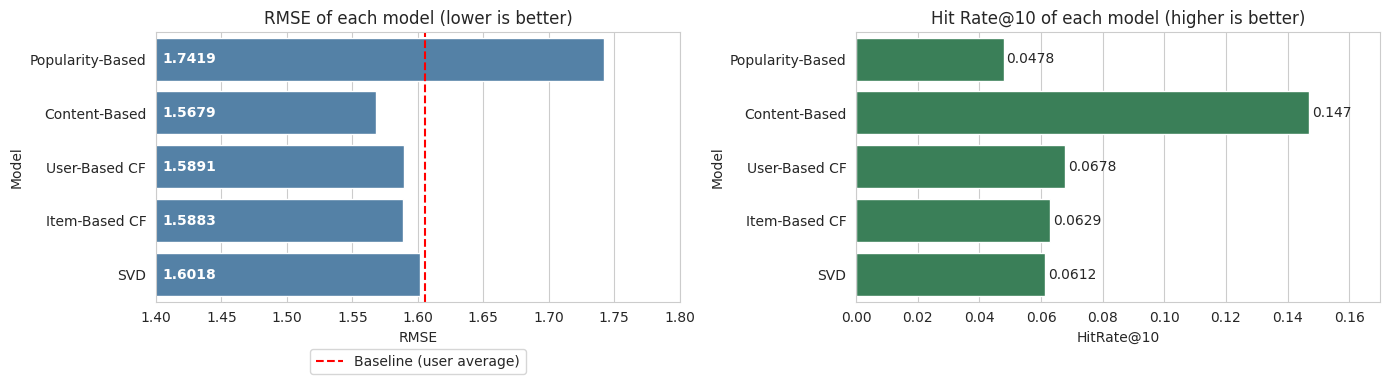

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(x='RMSE', y='Model', data=results_df, color='steelblue', ax=ax[0])
ax[0].axvline(baseline_rmse, color='red', linestyle='--', label='Baseline (user average)')
ax[0].set_xlim(1.4, 1.8)
ax[0].set_title('RMSE of each model (lower is better)')
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))
for i, v in enumerate(results_df['RMSE']):
    ax[0].text(1.405, i, str(v), va='center', color='white', fontweight='bold')

sns.barplot(x='HitRate@10', y='Model', data=results_df, color='seagreen', ax=ax[1])
ax[1].set_xlim(0, 0.17)
ax[1].set_title('Hit Rate@10 of each model (higher is better)')
for i, v in enumerate(results_df['HitRate@10']):
    ax[1].text(v + 0.001, i, str(v), va='center')

plt.tight_layout()
plt.show()

**What is this graph for?** It compares all five models side by side. The left graph is the error in predicting ratings (smaller bar is better, the red dashed line is the baseline of simply predicting each user's own average, and the axis starts at 1.4 so the small differences are visible) and the right graph is how often the top-10 list contained at least one book the user liked (bigger bar is better).

**What we see:** - **Content-Based** gives the best results on both tests: lowest RMSE (1.568) and highest Hit Rate@10 (about 14.7%, which is roughly 3 times the popularity model). People often read more books from the same author / series, and the tags capture exactly this.
- **User-Based CF, Item-Based CF and SVD** are only slightly better than the simple baseline of predicting the user's own average (RMSE 1.605). The reason is the sparsity - only 0.44% of the matrix is filled, so there is little overlap between users and books to learn from.
- **Popularity-Based** has the worst RMSE (1.742) because it gives the same score to everyone, but it is still useful for new users who have no history.

## 10. Getting Recommendations
Functions to get the top-N books for a user from any model, and to find books similar to a given book.

In [42]:
# all books each user has rated (train + test) - these are not recommended again
seen_all = df.groupby('u')['i'].apply(list).to_dict()

def recommend_books(user_id, model_name='SVD', n=10):
    if user_id not in user2idx:
        print('User not in the modelling data -> showing popular books (cold start)')
        model_name = 'Popularity-Based'
        u = 0
    else:
        u = user2idx[user_id]
    s = all_scores[model_name][u].astype(float).copy()
    s[seen_all.get(u, [])] = -np.inf
    top = np.argsort(-s)[:n * 3]            # take extra, because the same title can have more than one ISBN
    out = items_df.loc[top, ['title', 'author', 'year']].copy()
    out['predicted_score'] = s[top].round(2)
    out = out.drop_duplicates(subset='title').head(n)
    return out.reset_index(drop=True)

def similar_books(title_text, method='Item-Based CF', n=5):
    match = items_df[items_df['title'].str.contains(title_text, case=False, regex=False)]
    if match.empty:
        return 'Book not found in the modelling data'
    idx = match.index[0]
    sim = item_sim_full[idx] if method == 'Item-Based CF' else content_sim[idx]
    top = np.argsort(-sim)
    top = [t for t in top if t != idx][:n]
    out = items_df.loc[top, ['title', 'author']].copy()
    out['similarity'] = sim[top].round(3)
    print('Books similar to:', items_df.loc[idx, 'title'], '| method:', method)
    return out.reset_index(drop=True)

In [43]:
# pick an example user with a good number of ratings
example_user = df['user_id'].value_counts().index[20]
print('Example user:', example_user)

print('\nBooks this user rated highly:')
liked = df[(df['user_id'] == example_user) & (df['rating'] >= 8)].merge(items_df[['isbn', 'title', 'author']], on='isbn')
display(liked[['title', 'author', 'rating']].head(8))

Example user: 31315

Books this user rated highly:


,title,author,rating
0,Dr. Atkins' New Diet Revolution,Robert C. Atkins,9
1,Little House on the Prairie,Laura Ingalls Wilder,8
2,Icy Sparks,Gwyn Hyman Rubio,9
3,Coming Home,Rosamunde Pilcher,8
4,Eva Moves the Furniture: A Novel,Margot Livesey,8
5,September,Rosamunde Pilcher,8
6,The Dogs of Babel (Today Show Book Club #12),Carolyn Parkhurst,9
7,Cradle and All,James Patterson,10


In [44]:
print('--- Popularity-Based ---')
display(recommend_books(example_user, 'Popularity-Based'))

--- Popularity-Based ---


,title,author,year,predicted_score
0,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,2000,9.01
1,"The Return of the King (The Lord of the Rings, Part 3)",J.R.R. TOLKIEN,1986,8.92
2,Harry Potter and the Sorcerer's Stone (Harry Potter (Pap...,J. K. Rowling,1999,8.90
3,Harry Potter and the Order of the Phoenix (Book 5),J. K. Rowling,2003,8.87
4,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,1999,8.85
5,To Kill a Mockingbird,Harper Lee,1988,8.77
6,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,1999,8.76
7,Dune (Remembering Tomorrow),Frank Herbert,1996,8.72
8,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,1986,8.71
9,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,1998,8.71


In [45]:
print('--- Content-Based ---')
display(recommend_books(example_user, 'Content-Based'))

--- Content-Based ---


,title,author,year,predicted_score
0,The Second Time Around : A Novel,Mary Higgins Clark,2003,9.81
1,The Jester,James Patterson,2003,9.80
2,The Lake House,James Patterson,2003,9.80
3,The Beach House,James Patterson,2002,9.80
4,Remember Me,Mary Higgins Clark,1995,9.80
5,Four Blind Mice,James Patterson,2003,9.80
6,Violets Are Blue,James Patterson,2002,9.79
7,See How They Run,James Patterson,1997,9.79
8,2nd Chance,James Patterson,2003,9.79
9,When the Wind Blows,James Patterson,1999,9.79


In [46]:
print('--- User-Based CF ---')
display(recommend_books(example_user, 'User-Based CF'))

--- User-Based CF ---


,title,author,year,predicted_score
0,Life of Pi,Yann Martel,2002,9.39
1,Hearts In Atlantis,Stephen King,2000,9.36
2,The Boy Next Door,Meggin Cabot,2002,9.31
3,Atonement: A Novel,Ian McEwan,2002,9.31
4,To Kill a Mockingbird,Harper Lee,1988,9.26
5,"Ahab's Wife: Or, The Star-Gazer: A Novel",Sena Jeter Naslund,1999,9.25
6,More Than Complete Hitchhiker's Guide,Douglas Adams,1990,9.25
7,It's My F---ing Birthday : A Novel,MERRILL MARKOE,2002,9.25
8,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,1995,9.18
9,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,2000,9.18


In [47]:
print('--- Item-Based CF ---')
display(recommend_books(example_user, 'Item-Based CF'))

--- Item-Based CF ---


,title,author,year,predicted_score
0,The Devil's Code,John Sandford,2000,9.67
1,Miracle Cure,Michael Palmer,1999,9.66
2,Serpent's Tooth: A Peter Decker/Rina Lazarus Novel (Pete...,Faye Kellerman,1997,9.62
3,Rebellious Desire,Julie Garwood,1991,9.53
4,Heartbreaker,Julie Garwood,2001,9.53
5,Neanderthal: A Novel,John Darnton,1997,9.52
6,"Loves Music, Loves to Dance",Mary Higgins Clark,1991,9.52
7,I Am Legend,Richard Matheson,1997,9.46
8,A Second Chicken Soup for the Woman's Soul (Chicken Soup...,Jack Canfield,1998,9.46
9,In the Time of the Butterflies,Julia Alvarez,1995,9.45


In [48]:
print('--- SVD ---')
display(recommend_books(example_user, 'SVD'))

--- SVD ---


,title,author,year,predicted_score
0,Timeline,MICHAEL CRICHTON,2000,8.99
1,The Boy Next Door,Meggin Cabot,2002,8.95
2,Hearts In Atlantis,Stephen King,2000,8.92
3,She's Come Undone (Oprah's Book Club (Paperback)),Wally Lamb,1996,8.92
4,The English Patient,Michael Ondaatje,1996,8.91
5,Dreamcatcher,Stephen King,2001,8.90
6,Still Waters,TAMI HOAG,1992,8.90
7,Life of Pi,Yann Martel,2002,8.90
8,The Plains of Passage (Earth's Children (Paperback)),JEAN M. AUEL,1991,8.88
9,Hornet's Nest,Patricia Daniels Cornwell,1998,8.87


**Similar book search** (example using the most rated book in the data)

In [49]:
famous_title = items_df.loc[train['i'].value_counts().index[0], 'title']
display(similar_books(famous_title, 'Item-Based CF'))
display(similar_books(famous_title, 'Content-Based'))

Books similar to: The Lovely Bones: A Novel | method: Item-Based CF


,title,author,similarity
0,The Dress Lodger,Sheri Holman,0.200
1,Flesh and Blood,Jonathan Kellerman,0.193
2,Three Junes,Julia Glass,0.175
3,SECRET DIARY OF LAURA PALMER (TWIN PEAKS) (A Twin Peaks ...,Jennifer Lynch,0.135
4,Atlantis Found,Clive Cussler,0.119


Books similar to: The Lovely Bones: A Novel | method: Content-Based


,title,author,similarity
0,The Lovely Bones,Alice Sebold,0.904
1,Lucky,Alice Sebold,0.676
2,Lucky : A Memoir,Alice Sebold,0.630
3,Bag of Bones,Stephen King,0.160
4,BAG OF BONES : A NOVEL,Stephen King,0.154


## 11. Conclusion

**Summary**
- Data: 1.15M ratings, but only about 37% are explicit (1-10) and the data is extremely sparse (median 1 rating per user and per book).
- Feature engineering: user features (rating count, average rating, age group, country, user type), book features (rating count, average rating, weighted rating, decade, title length, author / publisher counts) and a `tags` text column for content similarity.
- For modelling we used explicit ratings with users >= 6 ratings and books >= 8 ratings (74,768 ratings, 4,289 users, 4,001 books) and an 80/20 train-test split.

**Model results** (test data)

| Model | RMSE | Hit Rate@10 |
| --- | --- | --- |
| Baseline (user average) | 1.605 | - |
| Popularity-Based | 1.742 | 0.048 |
| Content-Based | **1.568** | **0.147** |
| User-Based CF | 1.589 | 0.068 |
| Item-Based CF | 1.588 | 0.063 |
| SVD | 1.602 | 0.061 |

**Best model: Content-Based Filtering** on this data. Use **Popularity-Based** as a fallback for new users (cold start).

**Limitations**
- The data is very sparse, so collaborative filtering and SVD barely beat the simple baseline.
- We removed about 94% of the users to get enough ratings per user, so the models work only for users / books that are in the filtered data.
- The best `k` and `n_components` were selected using the test data for simplicity. For the final version a separate validation set should be used.
- The same book can appear more than once with different ISBNs (different editions). We remove repeated titles only while showing the recommendations.
- Content similarity is only based on author, publisher and title words, so some pairs look similar only because of a shared word (for example 'Bones').

**Next steps**
- Build a Hybrid model (Content-Based + Item-Based CF + Popularity for new users).
- Try the implicit (0) ratings as a signal and try other models such as ALS.
- Deploy the best model with Streamlit / Flask as per the project plan.